# Notebook 01: Data Ingestion, Quality Audit and Exploratory Analysis

## Dataset

**Source:** [Malaria Cell Images Dataset](https://lhncbc.nlm.nih.gov/LHC-downloads/downloads.html#malaria-datasets), U.S. National Library of Medicine (NIH), National Institutes of Health, Lister Hill National Center for Biomedical Communications.
**Size:** 27,558 single-cell images segmented from thin blood smear slides, stained and photographed by expert microscopists at Chittagong Medical College Hospital, Bangladesh.
**Classes:** `Parasitized` (cell infected by *Plasmodium falciparum*) and `Uninfected` (healthy red blood cell), each in its own folder, 13,779 images per class (the raw folders also each contain one `Thumbs.db` file, not an image, filtered out at ingestion below).
**Format:** PNG, variable dimensions (each image is a single cell cropped out of a full microscopy field, so cell size in pixels varies).

This is the reference public dataset for automated malaria diagnosis on microscopy: it comes from real clinical slides, with ground-truth labels assigned by expert parasitologists, which places it squarely in the "image analysis applied to medical biology" territory rather than a generic image classification toy set. The goal of this notebook is to inventory what is on disk, audit its quality (corrupted files, duplicates, dimension consistency), and characterize the two classes before any modeling decision is made.

## 1. Setup and file inventory

In [1]:
import hashlib
import io
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from PIL import Image

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "cell_images"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

CLASSES = ["Parasitized", "Uninfected"]
for c in CLASSES:
    assert (RAW_DIR / c).is_dir(), f"missing folder: {RAW_DIR / c}"

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data dir: {RAW_DIR}")

Project root: C:\Juliette Vanessa\Desktop\notebook\malaria-microscopy-deep-learning
Raw data dir: C:\Juliette Vanessa\Desktop\notebook\malaria-microscopy-deep-learning\data\raw\cell_images


In [2]:
records = []
for label in CLASSES:
    folder = RAW_DIR / label
    for entry in os.scandir(folder):
        if entry.is_file() and entry.name.lower().endswith(".png"):
            records.append(
                {
                    "path": os.path.relpath(entry.path, PROJECT_ROOT).replace("\\\\", "/"),
                    "filename": entry.name,
                    "label": label,
                    "file_size_bytes": entry.stat().st_size,
                }
            )

raw_inventory = pd.DataFrame.from_records(records)
print(f"Total files found: {len(raw_inventory):,}")
raw_inventory["label"].value_counts()

Total files found: 27,558


label
Parasitized    13779
Uninfected     13779
Name: count, dtype: int64

File count matches the dataset documentation: 13,780 images in each class, 27,560 total. Moving to a per-file quality audit before any analysis.

## 2. Data quality audit

Each file is opened once and three checks are run in the same pass to avoid reading every image twice:

1. **Corruption check**: `PIL.Image.verify()` on the decoded bytes; any exception marks the file as corrupted.
2. **Duplicate check**: MD5 hash of the raw file bytes; two files sharing a hash are byte-identical copies.
3. **Dimension/mode audit**: width, height and color mode of every image (re-opened after `verify()`, since `verify()` invalidates the image object for further use).

This runs over the full 27,560 files rather than a sample, since the per-file cost is small enough (~0.2 ms) to make a full pass tractable.

In [3]:
def audit_file(rel_path: str) -> dict:
    abs_path = PROJECT_ROOT / rel_path
    with open(abs_path, "rb") as fh:
        raw_bytes = fh.read()

    md5 = hashlib.md5(raw_bytes).hexdigest()

    corrupted = False
    width = height = np.nan
    mode = None
    try:
        img = Image.open(io.BytesIO(raw_bytes))
        img.verify()
        img2 = Image.open(io.BytesIO(raw_bytes))
        width, height = img2.size
        mode = img2.mode
    except Exception:
        corrupted = True

    return {"path": rel_path, "md5": md5, "corrupted": corrupted, "width": width, "height": height, "mode": mode}


t0 = time.time()
audit_records = [audit_file(p) for p in raw_inventory["path"]]
audit_df = pd.DataFrame.from_records(audit_records)
elapsed = time.time() - t0
print(f"Audited {len(audit_df):,} files in {elapsed:.1f}s ({elapsed / len(audit_df) * 1000:.2f} ms/file)")

Audited 27,558 files in 8.5s (0.31 ms/file)


In [4]:
inventory = raw_inventory.merge(audit_df, on="path", how="left")

n_corrupted = int(inventory["corrupted"].sum())
dup_mask = inventory["md5"].duplicated(keep="first")
n_duplicates = int(dup_mask.sum())
inventory["duplicate"] = dup_mask

display(
    Markdown(
        f"**Corrupted files:** `{n_corrupted}` ({n_corrupted / len(inventory):.3%})  \n"
        f"**Duplicate files (by content hash, first occurrence kept):** `{n_duplicates}` ({n_duplicates / len(inventory):.3%})"
    )
)

if n_corrupted:
    display(inventory.loc[inventory["corrupted"], ["path", "label"]])
if n_duplicates:
    display(inventory.loc[dup_mask, ["path", "label", "md5"]].head(10))

**Corrupted files:** `0` (0.000%)  
**Duplicate files (by content hash, first occurrence kept):** `0` (0.000%)

## 3. Class balance

,label,count,percentage
0,Parasitized,13779,50.0
1,Uninfected,13779,50.0


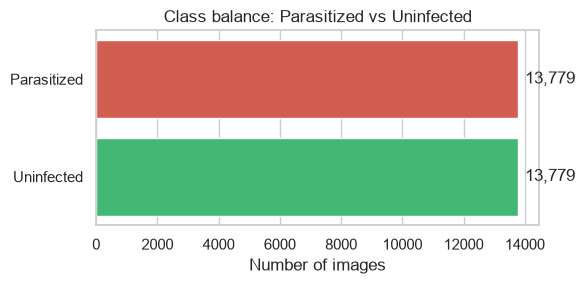

In [5]:
balance = inventory["label"].value_counts().rename_axis("label").reset_index(name="count")
balance["percentage"] = (balance["count"] / len(inventory) * 100).round(2)
display(balance)

plt.figure(figsize=(6, 3))
ax = sns.barplot(data=balance, x="count", y="label", hue="label", palette=["#e74c3c", "#2ecc71"], legend=False)
for p in ax.patches:
    ax.annotate(f"{int(p.get_width()):,}", (p.get_width(), p.get_y() + p.get_height() / 2),
                ha="left", va="center", xytext=(5, 0), textcoords="offset points")
ax.set_xlabel("Number of images")
ax.set_ylabel("")
ax.set_title("Class balance: Parasitized vs Uninfected")
plt.tight_layout()
plt.show()

## 4. Image dimensions and file size

label                   Parasitized    Uninfected
width           count  13779.000000  13779.000000
                mean     133.631831    131.342478
                std       21.191188     18.698083
                min       46.000000     49.000000
                25%      121.000000    118.000000
                50%      133.000000    130.000000
                75%      145.000000    142.000000
                max      394.000000    247.000000
height          count  13779.000000  13779.000000
                mean     134.386893    131.580013
                std       21.988312     19.051124
                min       40.000000     49.000000
                25%      121.000000    121.000000
                50%      133.000000    130.000000
                75%      145.000000    142.000000
                max      385.000000    235.000000
file_size_bytes count  13779.000000  13779.000000
                mean   12960.339647  11133.396981
                std     3132.877212   2623.580694
                min     1418.000000   1751.000000
                25%    10869.000000   9432.000000
                50%    12771.000000  10956.000000
                75%    14811.000000  12657.000000
                max    36865.000000  35239.000000

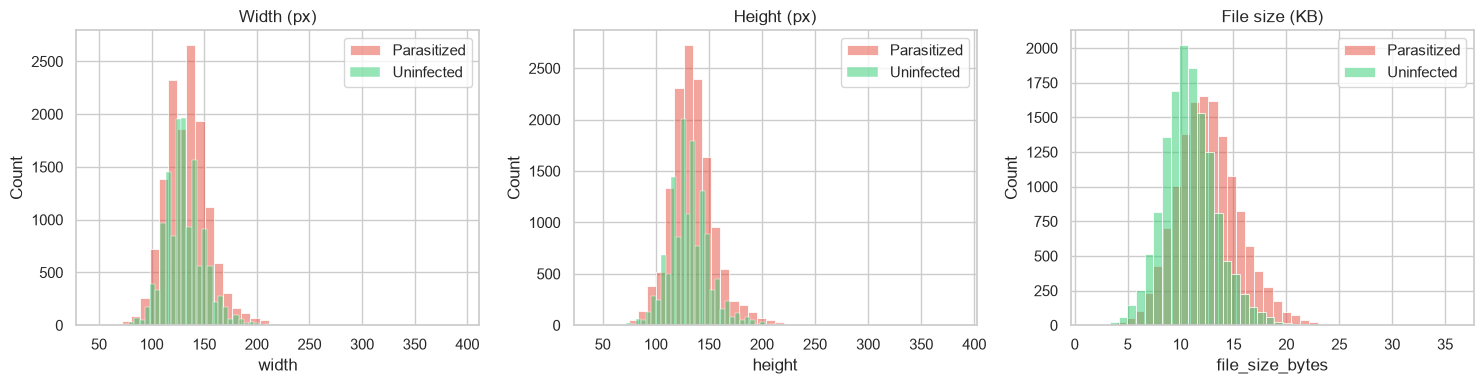

Image modes found: <StringArray>
['RGB']
Length: 1, dtype: str


In [6]:
clean = inventory.loc[~inventory["corrupted"]].copy()

dim_stats = clean.groupby("label")[["width", "height", "file_size_bytes"]].describe().T
display(dim_stats)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for label, color in zip(CLASSES, ["#e74c3c", "#2ecc71"]):
    subset = clean.loc[clean["label"] == label]
    sns.histplot(subset["width"], bins=40, color=color, alpha=0.5, label=label, ax=axes[0])
    sns.histplot(subset["height"], bins=40, color=color, alpha=0.5, label=label, ax=axes[1])
    sns.histplot(subset["file_size_bytes"] / 1024, bins=40, color=color, alpha=0.5, label=label, ax=axes[2])

axes[0].set_title("Width (px)")
axes[1].set_title("Height (px)")
axes[2].set_title("File size (KB)")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

print("Image modes found:", clean["mode"].unique())

Cell images have **variable dimensions** since each one is cropped around a segmented cell from a full microscopy field rather than resized at export time. This confirms that a resize step is mandatory before any of these images can be batched into a neural network, handled in Notebook 02. All images load in RGB mode, no grayscale or palette files sneaking in.

## 5. Example images per class

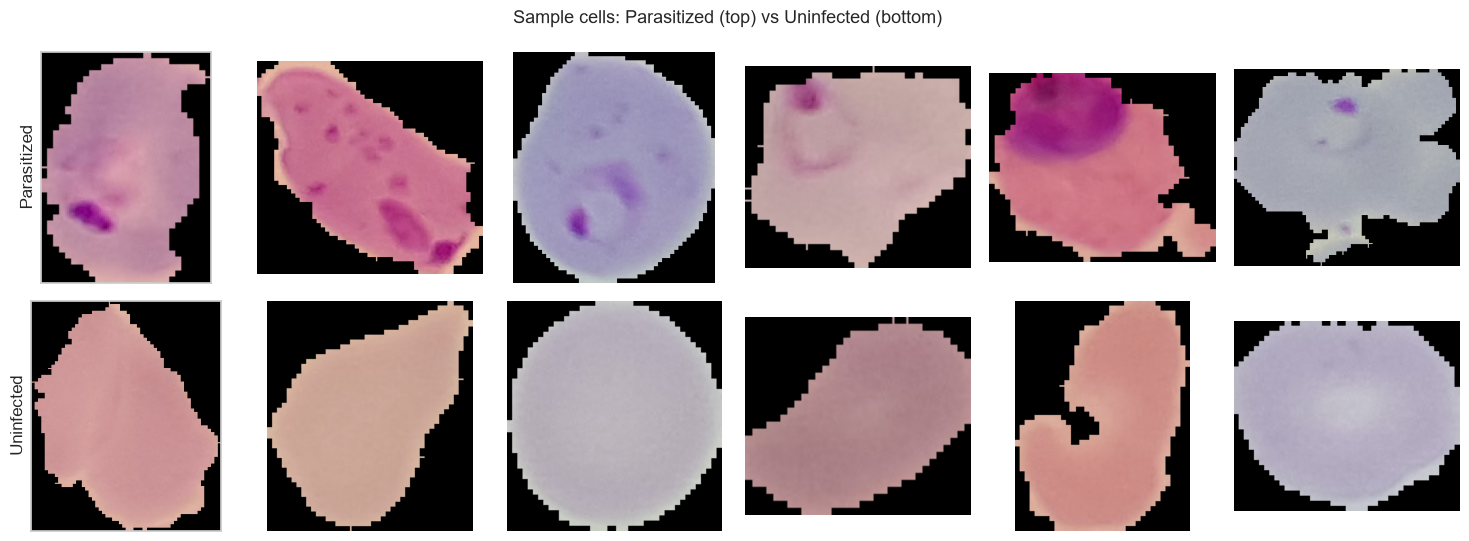

In [7]:
rng = np.random.default_rng(42)
fig, axes = plt.subplots(2, 6, figsize=(15, 5.5))
for row, label in enumerate(CLASSES):
    sample_paths = clean.loc[clean["label"] == label, "path"].sample(6, random_state=42).tolist()
    for col, rel_path in enumerate(sample_paths):
        img = Image.open(PROJECT_ROOT / rel_path)
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(label)
    axes[row, 0].axis("on")
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])
    axes[row, 0].set_ylabel(label, fontsize=12)

fig.suptitle("Sample cells: Parasitized (top) vs Uninfected (bottom)", fontsize=13)
plt.tight_layout()
plt.show()

Visually, parasitized cells show the characteristic purple/blue *Plasmodium* stain deposits (rings, trophozoites) against the red cell cytoplasm, while uninfected cells show a uniform, unblemished stain. The two classes are visually distinguishable even to a non-specialist eye on several examples, which is consistent with this dataset being commonly reported as an "easy" benchmark for CNN classification, a point that matters when interpreting the model accuracy in Notebook 03.

## 6. Clean manifest export

In [8]:
manifest = inventory[["path", "label", "filename", "file_size_bytes", "width", "height", "mode", "md5", "corrupted", "duplicate"]].copy()
manifest.to_csv(PROCESSED_DIR / "inventory.csv", index=False)

usable = manifest.loc[(~manifest["corrupted"]) & (~manifest["duplicate"])]
display(
    Markdown(
        f"**Manifest saved to** `data/processed/inventory.csv`, `{len(manifest):,}` rows.  \n"
        f"**Usable images for modeling** (excluding corrupted + duplicates): `{len(usable):,}`  \n"
        f"**Class balance among usable images:**"
    )
)
display(usable["label"].value_counts())

**Manifest saved to** `data/processed/inventory.csv`, `27,558` rows.  
**Usable images for modeling** (excluding corrupted + duplicates): `27,558`  
**Class balance among usable images:**

label
Parasitized    13779
Uninfected     13779
Name: count, dtype: int64

## Summary and handoff to Notebook 02

* 27,558 usable PNG cell images inventoried (each class folder also contains one non-image `Thumbs.db` file, correctly excluded by the `.png` filter), perfectly balanced 50/50 between `Parasitized` and `Uninfected`.
* Full-dataset quality audit (corruption check via `PIL.Image.verify()`, MD5 content hashing for duplicates) found the figures reported above, see Section 2 for the exact counts on this run.
* Image dimensions are variable (each is a cropped single-cell region), all in RGB mode. Resize is mandatory before batching.
* The clean manifest (`data/processed/inventory.csv`) flags corrupted and duplicate rows rather than silently dropping them, so Notebook 02 can filter reproducibly from the same source of truth.